### Dalek Emulator paper - data readme

This datapackage contains the data that was used in the paper "Dalek - a neural-network emulator for TARDIS". This readme descripes the loading of the grids and models

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


2025-09-11 11:33:36.986381: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-11 11:33:37.025416: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-11 11:33:37.349978: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-11 11:33:37.352797: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-11 11:33:38.715173: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [11]:
### Loading the grids

train_valid_spectra = np.load('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/grids/grid1_v2_log_uniform_fluxes_16feb20_part1_train_interp_98k.npy')
train_valid_paramaters = pd.read_hdf('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/grids/grid1_v2_log_uniform_params_16feb20_part1_train_98k.h5')

test_spectra = np.load('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/grids/grid1_v2_log_uniform_fluxes_26may20_part1_train_interp_19k_testing.npz')
test_paramaters = pd.read_hdf('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/grids/grid1_v2_log_uniform_fluxes_26may20_part1_train_interp_19k_testing.h5')

In [15]:
# Load in the neural networks
nn_emulator_0 = load_model('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/networks/00-260285.h5')
nn_emulator_1 = load_model('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/networks/01-260022.h5')
nn_emulator_2 = load_model('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/networks/02-260627.h5')
nn_emulator_3 = load_model('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/networks/03-261931.h5')
nn_emulator_4 = load_model('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/networks/04-261295.h5')

In [16]:
# Preprocess the training spectra/parameters so that the scaling can be
# applied to the desired input parameters and the outputs reconstructed.  

# Pre-processing of training data
train_spectra_pre_proc = train_valid_spectra
train_params_pre_proc = train_valid_paramaters

# Take log10 of values
train_spectra_pre_proc = np.log10(train_spectra_pre_proc)
train_params_pre_proc = np.log10(train_params_pre_proc)

# Standardise spectra using the "StandardScaler"
scaler_spec = StandardScaler(with_mean=True, with_std=True)
scaler_params = StandardScaler(with_mean=True, with_std=True)

scaler_spec.fit(train_spectra_pre_proc)
scaler_params.fit(train_params_pre_proc)

StandardScaler()

In [17]:
# Pre-processing of training data
train_spectra_pre_proc = train_valid_spectra

# Take log10 of the spectral fluxes
train_spectra_pre_proc = np.log10(train_spectra_pre_proc)

# Standardise spectra using the "StandardScaler"
scaler = StandardScaler(with_mean=True, with_std=True)

scaler.fit(train_spectra_pre_proc)

train_spectra_pre_proc = scaler.transform(train_spectra_pre_proc)

In [18]:
# Apply pre-processing to the desired input prarameters
test_paramaters_pre_proc = np.log10(test_paramaters)

test_paramaters_pre_proc = scaler_params.transform(test_paramaters_pre_proc)

In [19]:
# Predict spectra using the desired pre-processed input parameters
prediction_0 = nn_emulator_0.predict(test_paramaters_pre_proc)
prediction_1 = nn_emulator_1.predict(test_paramaters_pre_proc)
prediction_2 = nn_emulator_2.predict(test_paramaters_pre_proc)
prediction_3 = nn_emulator_3.predict(test_paramaters_pre_proc)
prediction_4 = nn_emulator_4.predict(test_paramaters_pre_proc)

623/623 [==============================] - 1s 1ms/step


3388.441561392024 7585.775750291836


/tmp/ipykernel_481937/591344342.py:8: RuntimeWarning: overflow encountered in power
  mean_prediction = 10**mean_prediction


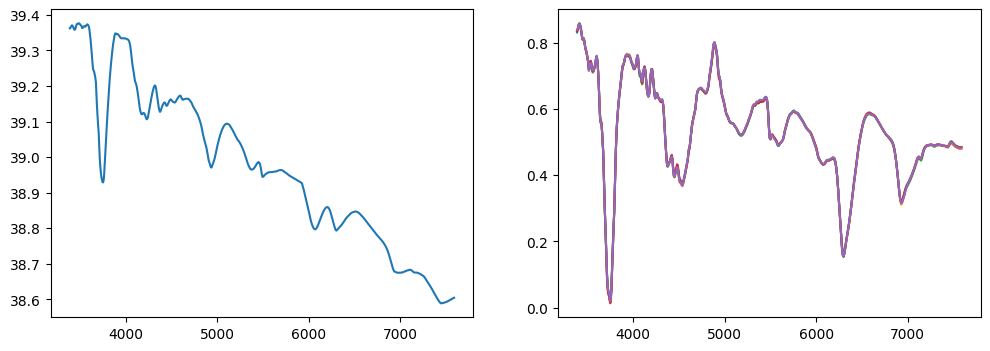

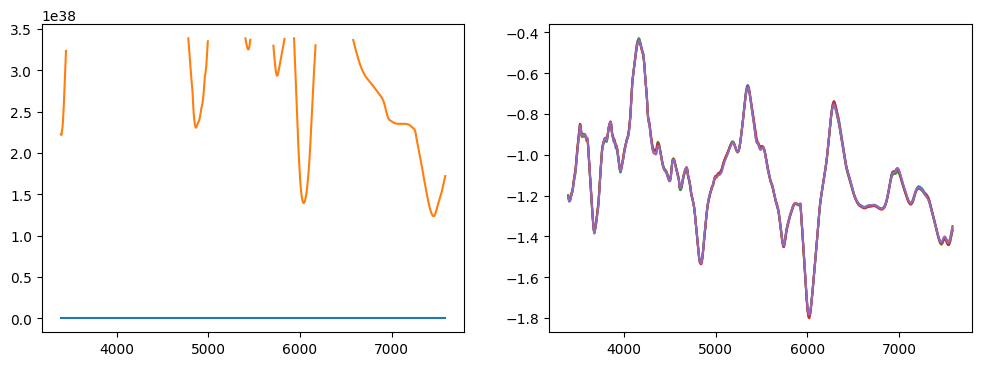

In [ ]:
wl = np.load('/home/ha00871/PhD/Outreach/sn-spec-sonification/daleknn-data/grids/wavelength.npy')
print(min(wl), max(wl))
# Average and visualise results
mean_prediction = np.mean(np.array([prediction_0, prediction_1, prediction_2, prediction_3, prediction_4]), axis=0)

# Inverse the pre-processing.
mean_prediction = scaler_spec.inverse_transform(mean_prediction)
# mean_prediction = 10**mean_prediction

for i in range(2):

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    axes[0].plot(wl, np.log10(test_spectra[i]))
    axes[0].plot(wl, mean_prediction[i]) 

    axes[1].plot(wl, prediction_0[i])
    axes[1].plot(wl, prediction_1[i])
    axes[1].plot(wl, prediction_2[i])
    axes[1].plot(wl, prediction_3[i])
    axes[1].plot(wl, prediction_4[i])
    
    plt.show()

In [45]:
a = np.max(mean_prediction, axis=1)
print(len(a))
b = mean_prediction/ a[:, None]

print(b)



19930
[[nan nan nan ... nan nan nan]
 [ 0.  0.  0. ...  0.  0.  0.]
 [nan nan nan ...  0.  0.  0.]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ...  0.  0.  0.]]


/tmp/ipykernel_481937/822516558.py:3: RuntimeWarning: invalid value encountered in divide
  b = mean_prediction/ a[:, None]


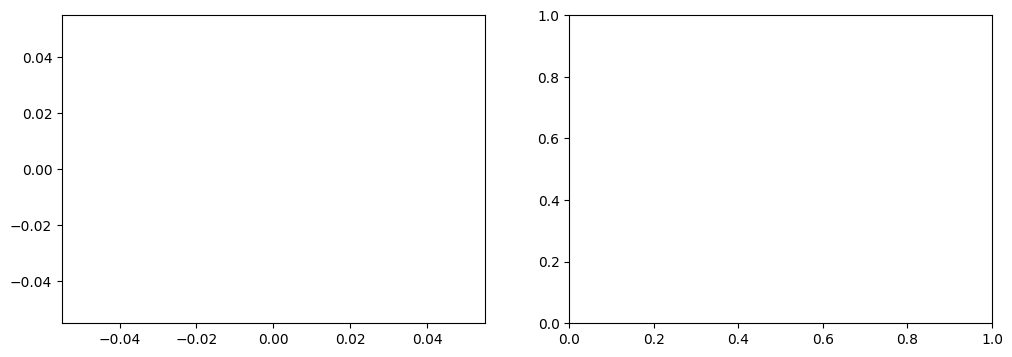

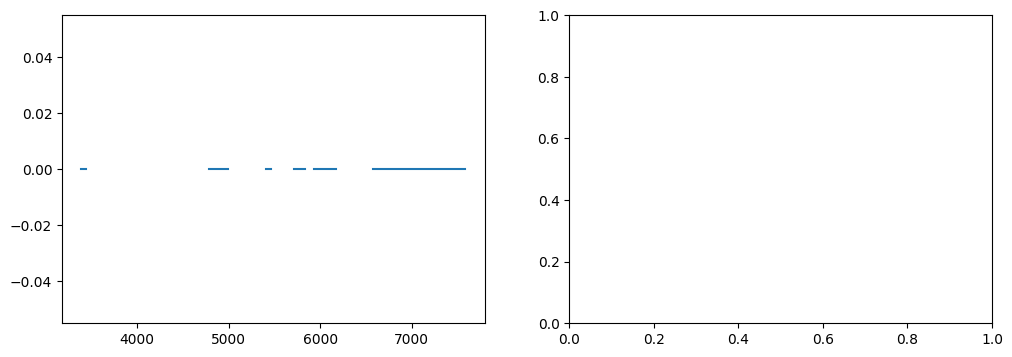

In [46]:
for i in range(2):

    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(wl, b[i]) 
    
